In [1]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt
from pmdarima import auto_arima, ARIMA
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error,root_mean_squared_error, r2_score

In [2]:
df= joblib.load(r"dataset\df.pkl")

In [3]:
df.head()

,#Passengers,month,quater,lag1,lag2,lag3,lag6,lag12,rolling_mean3,rolling_std3,rolling_mean6,rolling_std6,rolling_mean12,rolling_std12
Month,,,,,,,,,,,,,,
1949-01-01,112,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1949-02-01,118,2,1,112.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1949-03-01,132,3,1,118.0,112.0,NaN,NaN,NaN,120.666667,10.263203,NaN,NaN,NaN,NaN
1949-04-01,129,4,2,132.0,118.0,112.0,NaN,NaN,126.333333,7.371115,NaN,NaN,NaN,NaN
1949-05-01,121,5,2,129.0,132.0,118.0,NaN,NaN,127.333333,5.686241,NaN,NaN,NaN,NaN


In [4]:
df= df.asfreq('MS')

In [5]:
df.isnull().sum()

#Passengers       26
month             26
quater            26
lag1              27
lag2              28
lag3              29
lag6              32
lag12             38
rolling_mean3     28
rolling_std3      28
rolling_mean6     31
rolling_std6      31
rolling_mean12    37
rolling_std12     37
dtype: int64

In [6]:
df.bfill(inplace=True)

In [7]:
df.duplicated().sum()

np.int64(26)

In [8]:
df.drop_duplicates(keep='first', inplace=True)

In [9]:
df.shape

(118, 14)

In [10]:
df.head()

,#Passengers,month,quater,lag1,lag2,lag3,lag6,lag12,rolling_mean3,rolling_std3,rolling_mean6,rolling_std6,rolling_mean12,rolling_std12
Month,,,,,,,,,,,,,,
1949-01-01,112.0,1.0,1.0,112.0,112.0,112.0,112.0,112.0,120.666667,10.263203,124.5,8.916277,124.583333,12.153999
1949-02-01,118.0,2.0,1.0,112.0,112.0,112.0,112.0,112.0,120.666667,10.263203,124.5,8.916277,124.583333,12.153999
1949-03-01,132.0,3.0,1.0,118.0,112.0,112.0,112.0,112.0,120.666667,10.263203,124.5,8.916277,124.583333,12.153999
1949-04-01,129.0,4.0,2.0,132.0,118.0,112.0,112.0,112.0,126.333333,7.371115,124.5,8.916277,124.583333,12.153999
1949-05-01,121.0,5.0,2.0,129.0,132.0,118.0,112.0,112.0,127.333333,5.686241,124.5,8.916277,124.583333,12.153999


In [11]:
train= df.iloc[:-12, :].asfreq('MS')
test= df.iloc[-12:, :].asfreq('MS')

# ARIMA

Stationarity was checked explicitly in `main.ipynb` (ADF + KPSS, before and after differencing) — both tests agreed the raw series is non-stationary and a first difference is needed, consistent with the `d=1` that `auto_arima` selects below on its own via its internal stationarity search.

In [12]:
arima= auto_arima(
  train['#Passengers'].ffill(),
  seasonal=False
)

In [13]:
arima.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  128
Model:               SARIMAX(2, 1, 2)   Log Likelihood                -594.092
Date:                Sat, 08 Aug 2026   AIC                           1200.184
Time:                        13:24:45   BIC                           1217.249
Sample:                    01-01-1949   HQIC                          1207.118
                         - 08-01-1959                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.6259      0.169      3.693      0.000       0.294       0.958
ar.L1          1.6195      0.060     27.085      0.000       1.502       1.737
ar.L2         -0.8697      0.051    -16.920      0.000      -0.970      -0.769
ma.L1         -1.7630      0.094    -18.842      0.000      -1.946      -1.580
ma.L2          0.8097      0.090      9.008      0.000       0.633       0.986
sigma2       660.1700     62.195     10.614      0.000     538.270     782.070
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                47.49
Prob(Q):                              0.90   Prob(JB):                         0.00
Heteroskedasticity (H):               7.36   Skew:                            -0.40
Prob(H) (two-sided):                  0.00   Kurtosis:                         5.89
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [14]:
arima_forecast= arima.predict(len(test))

In [15]:
def model_evaluator(train,test,predictions, model:str):
  plt.figure(figsize=(10,4))
  plt.plot(train,label='train')
  plt.plot(test,label='test')
  plt.plot(predictions,label='Prediction')

  plt.legend(loc='best')
  plt.title(f'Forecast with {model}')
  plt.show()

  mae= round(mean_absolute_error(test,predictions), 2)
  mape= round(mean_absolute_percentage_error(test, predictions), 2) * 100
  r2= round(r2_score(test, predictions), 2)
  rmse= round(root_mean_squared_error(test,predictions), 2)

  print(f'mean absolute error: {mae}')
  print(f'mean absolute percentage error: {mape}%')
  print(f'r2 score: {r2}')
  print(f'root mean squared error: {rmse}')
  values= {'mae': mae, 'mape': mape, 'r2': r2, 'rmse': rmse}
  value= pd.DataFrame(values, index=[0])
  return value

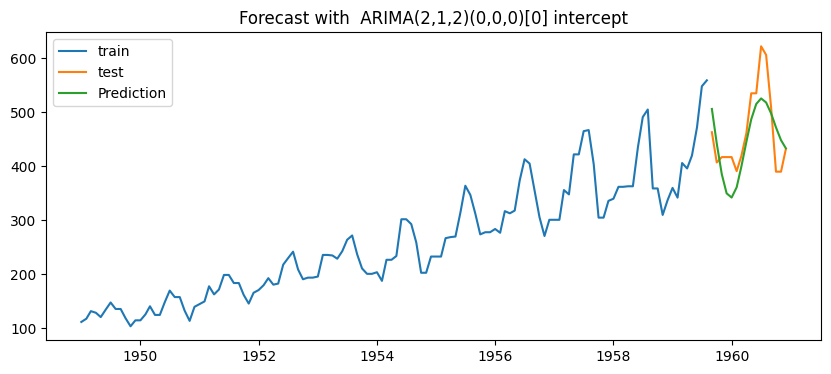

mean absolute error: 45.08
mean absolute percentage error: 10.0%
r2 score: 0.47
root mean squared error: 53.43


,mae,mape,r2,rmse
0,45.08,10.0,0.47,53.43


In [16]:
model_evaluator(train['#Passengers'].ffill(), test['#Passengers'].ffill(),arima_forecast, arima)

# Sarima

In [17]:
sarima= auto_arima(train['#Passengers'].ffill(),
                   seasonal=True,
                   m=12)

In [18]:
sarima.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                  y   No. Observations:                  128
Model:             SARIMAX(2, 0, 0)x(2, 1, 0, 12)   Log Likelihood                -505.562
Date:                            Sat, 08 Aug 2026   AIC                           1023.125
Time:                                    13:25:12   BIC                           1039.646
Sample:                                01-01-1949   HQIC                          1029.832
                                     - 08-01-1959                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     19.0080      5.763      3.298      0.001       7.712      30.304
ar.L1          0.4069      0.104      3.899      0.000       0.202       0.611
ar.L2          0.2316      0.112      2.074      0.038       0.013       0.450
ar.S.L12      -0.5621      0.092     -6.103      0.000      -0.743      -0.382
ar.S.L24      -0.1822      0.165     -1.105      0.269      -0.505       0.141
sigma2       344.3754     27.966     12.314      0.000     289.563     399.187
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                68.99
Prob(Q):                              0.98   Prob(JB):                         0.00
Heteroskedasticity (H):               5.78   Skew:                            -0.19
Prob(H) (two-sided):                  0.00   Kurtosis:                         6.76
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [19]:
sarima_pred= sarima.predict(len(test))

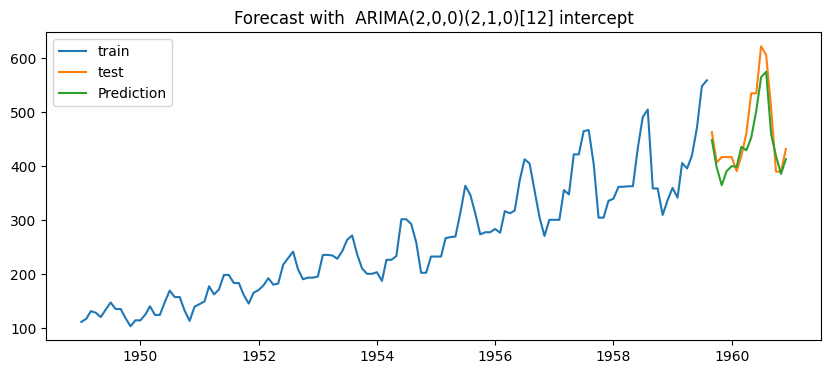

mean absolute error: 29.9
mean absolute percentage error: 6.0%
r2 score: 0.76
root mean squared error: 36.15


,mae,mape,r2,rmse
0,29.9,6.0,0.76,36.15


In [20]:
model_evaluator(train['#Passengers'].ffill(), test['#Passengers'].ffill(),sarima_pred, sarima)

# Sarimax

In [21]:
exog_train= train.drop(columns='#Passengers').bfill()
exog_test= test.drop(columns='#Passengers').bfill()

In [22]:
sarimax= auto_arima(train['#Passengers'].ffill(),
                    X= exog_train,
                    m=12,
                    seasonal=True,
                    )

In [23]:
sarimax.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  128
Model:                        SARIMAX   Log Likelihood                -494.416
Date:                Sat, 08 Aug 2026   AIC                           1016.833
Time:                        13:25:29   BIC                           1056.761
Sample:                    01-01-1949   HQIC                          1033.056
                         - 08-01-1959                                         
Covariance Type:                  opg                                         
==================================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
month             -2.5834      1.804     -1.432      0.152      -6.119       0.953
quater             9.2221      5.187      1.778      0.075      -0.945      19.389
lag1              -0.8706      0.122     -7.147      0.000      -1.109      -0.632
lag2              -0.7930      0.092     -8.659      0.000      -0.972      -0.613
lag3              -0.0401      0.130     -0.308      0.758      -0.295       0.215
lag6              -0.0057      0.070     -0.081      0.935      -0.143       0.131
lag12              0.0383      0.085      0.450      0.653      -0.129       0.205
rolling_mean3      2.7614      0.228     12.097      0.000       2.314       3.209
rolling_std3      -0.1966      0.143     -1.372      0.170      -0.477       0.084
rolling_mean6     -0.1741      0.224     -0.777      0.437      -0.613       0.265
rolling_std6       0.0466      0.233      0.200      0.842      -0.410       0.503
rolling_mean12     0.0302      0.239      0.127      0.899      -0.438       0.499
rolling_std12      0.2890      0.372      0.777      0.437      -0.440       1.018
sigma2           132.7290     16.616      7.988      0.000     100.161     165.297
===================================================================================
Ljung-Box (L1) (Q):                   0.79   Jarque-Bera (JB):               268.79
Prob(Q):                              0.37   Prob(JB):                         0.00
Heteroskedasticity (H):               4.11   Skew:                            -1.35
Prob(H) (two-sided):                  0.00   Kurtosis:                         9.56
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [24]:
sarimax_pred= sarimax.predict(len(test), X= exog_test)

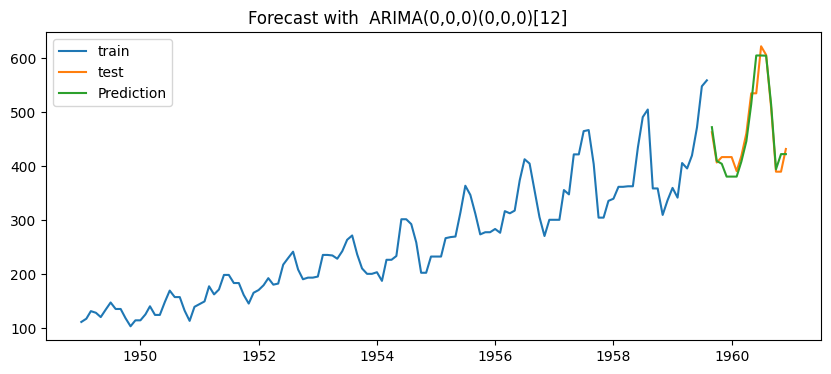

mean absolute error: 18.31
mean absolute percentage error: 4.0%
r2 score: 0.88
root mean squared error: 25.08


,mae,mape,r2,rmse
0,18.31,4.0,0.88,25.08


In [25]:
model_evaluator(train['#Passengers'].ffill(), test['#Passengers'].ffill(),sarimax_pred, sarimax)

### Why these search bounds

The first `auto_arima(seasonal=True, m=12)` call above used pmdarima's default stepwise search bounds. Here we widen the search (`max_p/max_q/max_P/max_Q=5`) and fix `d=1, D=1` based on the stationarity testing in `main.ipynb`, rather than letting the stepwise search re-derive them 
this trades a longer search time for a higher chance of finding a better-fitting order than the default stepwise search would settle on.

In [26]:
# Fine tunning 


fine_tuned_model = auto_arima(
    train['#Passengers'].ffill(),
    X=exog_train,
    m=12,
    seasonal=True,
    start_P=0, max_P=5,
    start_q=0, max_Q=3,
    start_p=0, max_p=3,
    start_Q=0, max_q=5,
    d=1, D=1,
    maxiter=2000,
    stepwise=True,
    trace=True,
    information_criterion='aic',
    suppress_warnings=True,
    error_action='ignore'
)

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=985.274, Time=0.66 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=945.394, Time=5.55 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=inf, Time=14.25 sec
 ARIMA(1,1,0)(0,1,0)[12]             : AIC=981.268, Time=3.25 sec
 ARIMA(1,1,0)(2,1,0)[12]             : AIC=937.684, Time=15.99 sec
 ARIMA(1,1,0)(3,1,0)[12]             : AIC=939.099, Time=22.67 sec
 ARIMA(1,1,0)(2,1,1)[12]             : AIC=939.405, Time=14.21 sec
 ARIMA(1,1,0)(1,1,1)[12]             : AIC=942.919, Time=8.09 sec
 ARIMA(1,1,0)(3,1,1)[12]             : AIC=inf, Time=29.03 sec
 ARIMA(0,1,0)(2,1,0)[12]             : AIC=948.446, Time=12.82 sec
 ARIMA(2,1,0)(2,1,0)[12]             : AIC=935.766, Time=23.66 sec
 ARIMA(2,1,0)(1,1,0)[12]             : AIC=946.102, Time=7.54 sec
 ARIMA(2,1,0)(3,1,0)[12]             : AIC=937.588, Time=26.43 sec
 ARIMA(2,1,0)(2,1,1)[12]             : AIC=937.660, Time=17.79 sec
 ARIMA(2,1,0)(1,1,1)[12]        

In [45]:
fine_tuned_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                  y   No. Observations:                  128
Model:             SARIMAX(3, 1, 0)x(2, 1, 0, 12)   Log Likelihood                -446.949
Date:                            Sat, 08 Aug 2026   AIC                            931.898
Time:                                    13:33:59   BIC                            984.052
Sample:                                01-01-1949   HQIC                           953.067
                                     - 08-01-1959                                         
Covariance Type:                              opg                                         
==================================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
month             -3.0701      1.544     -1.989      0.047      -6.096      -0.044
quater            12.3629      5.256      2.352      0.019       2.062      22.664
lag1              -0.6449      0.093     -6.919      0.000      -0.828      -0.462
lag2              -0.4723      0.060     -7.826      0.000      -0.591      -0.354
lag3              -0.3299      0.087     -3.771      0.000      -0.501      -0.158
lag6              -0.0555      0.046     -1.216      0.224      -0.145       0.034
lag12              0.0073      0.055      0.133      0.894      -0.101       0.116
rolling_mean3      2.0331      0.191     10.662      0.000       1.659       2.407
rolling_std3      -0.1872      0.115     -1.623      0.105      -0.413       0.039
rolling_mean6      0.4275      0.200      2.136      0.033       0.035       0.820
rolling_std6       0.2556      0.156      1.633      0.102      -0.051       0.562
rolling_mean12    -0.3195      0.319     -1.002      0.316      -0.944       0.305
rolling_std12     -0.4230      0.525     -0.805      0.421      -1.453       0.607
ar.L1             -1.0412      0.112     -9.302      0.000      -1.261      -0.822
ar.L2             -0.6606      0.144     -4.585      0.000      -0.943      -0.378
ar.L3             -0.2813      0.106     -2.651      0.008      -0.489      -0.073
ar.S.L12          -0.9178      0.122     -7.534      0.000      -1.157      -0.679
ar.S.L24          -0.5290      0.150     -3.520      0.000      -0.823      -0.234
sigma2           122.7529     21.239      5.780      0.000      81.126     164.380
===================================================================================
Ljung-Box (L1) (Q):                   0.24   Jarque-Bera (JB):                 8.01
Prob(Q):                              0.62   Prob(JB):                         0.02
Heteroskedasticity (H):               5.34   Skew:                            -0.33
Prob(H) (two-sided):                  0.00   Kurtosis:                         4.11
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [28]:
fine_tuned_model.get_params

<bound method BaseEstimator.get_params of ARIMA(maxiter=2000, order=(3, 1, 0), scoring_args={},
      seasonal_order=(2, 1, 0, 12), suppress_warnings=True,
      with_intercept=False)>

In [29]:
forecast= fine_tuned_model.predict(n_periods=len(test), X= exog_test)

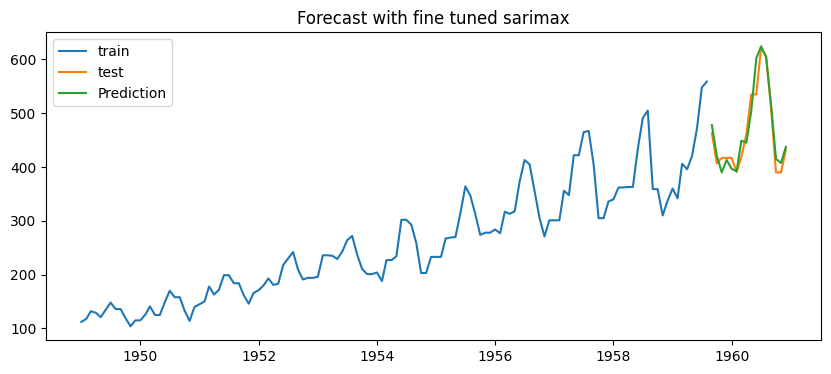

mean absolute error: 17.83
mean absolute percentage error: 4.0%
r2 score: 0.89
root mean squared error: 24.03


In [30]:
sarimax_metric=model_evaluator(train['#Passengers'].ffill(), test['#Passengers'].ffill(),forecast, 'fine tuned sarimax')

In [31]:
sarimax_metric.to_csv('dataset\\sarimax_metric.csv')

In [32]:
df= df.asfreq('MS')
df_exog= df.drop(columns='#Passengers').bfill()

In [57]:
# Future prediction model
# "The final model order was selected based on the lowest AIC obtained during the fine-tuning search."

final_model= ARIMA(order=(3, 1, 0), seasonal_order=(2, 1, 0, 12),maxiter=1000)



In [58]:

final_model.fit(y=df['#Passengers'].ffill(), X=df_exog)

,order,"(3, ...)"
,seasonal_order,"(2, ...)"
,start_params,None
,method,'lbfgs'
,maxiter,1000
,suppress_warnings,False
,out_of_sample_size,0
,scoring,'mse'
,scoring_args,None
,trend,None
,with_intercept,True


In [59]:
final_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                  y   No. Observations:                  144
Model:             SARIMAX(3, 1, 0)x(2, 1, 0, 12)   Log Likelihood                -527.811
Date:                            Sat, 08 Aug 2026   AIC                           1095.622
Time:                                    13:38:33   BIC                           1153.126
Sample:                                01-01-1949   HQIC                          1118.988
                                     - 12-01-1960                                         
Covariance Type:                              opg                                         
==================================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
intercept          0.1886      1.512      0.125      0.901      -2.774       3.151
month             -3.3612      1.754     -1.916      0.055      -6.799       0.077
quater            11.8676      6.121      1.939      0.053      -0.130      23.865
lag1              -0.5654      0.096     -5.874      0.000      -0.754      -0.377
lag2              -0.5350      0.070     -7.608      0.000      -0.673      -0.397
lag3              -0.2077      0.084     -2.476      0.013      -0.372      -0.043
lag6              -0.0308      0.044     -0.701      0.483      -0.117       0.055
lag12             -0.0197      0.041     -0.483      0.629      -0.099       0.060
rolling_mean3      1.9887      0.182     10.900      0.000       1.631       2.346
rolling_std3      -0.1940      0.078     -2.475      0.013      -0.348      -0.040
rolling_mean6      0.3336      0.196      1.699      0.089      -0.051       0.719
rolling_std6       0.2187      0.181      1.209      0.227      -0.136       0.573
rolling_mean12    -0.3118      0.273     -1.143      0.253      -0.846       0.223
rolling_std12     -0.6482      0.487     -1.330      0.184      -1.604       0.307
ar.L1             -1.0257      0.138     -7.440      0.000      -1.296      -0.755
ar.L2             -0.7607      0.178     -4.263      0.000      -1.110      -0.411
ar.L3             -0.3651      0.128     -2.849      0.004      -0.616      -0.114
ar.S.L12          -0.9823      0.118     -8.300      0.000      -1.214      -0.750
ar.S.L24          -0.6343      0.100     -6.313      0.000      -0.831      -0.437
sigma2           159.9478     23.777      6.727      0.000     113.346     206.549
===================================================================================
Ljung-Box (L1) (Q):                   0.54   Jarque-Bera (JB):                29.91
Prob(Q):                              0.46   Prob(JB):                         0.00
Heteroskedasticity (H):               8.23   Skew:                            -0.57
Prob(H) (two-sided):                  0.00   Kurtosis:                         5.05
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [60]:
last_date= df.index[-1]
last_date

Timestamp('1960-12-01 00:00:00')

In [61]:
period= 12

future_dates= pd.date_range(
  start=last_date + pd.DateOffset(months=1),
  periods=period ,
  freq='MS'
)

In [62]:
future_dates

DatetimeIndex(['1961-01-01', '1961-02-01', '1961-03-01', '1961-04-01',
               '1961-05-01', '1961-06-01', '1961-07-01', '1961-08-01',
               '1961-09-01', '1961-10-01', '1961-11-01', '1961-12-01'],
              dtype='datetime64[ns]', freq='MS')

In [63]:
future_data= pd.DataFrame(index=future_dates)

In [64]:

def build_exog_row(model, history, future_dates_df, target_col="#Passengers"):
 
    history = history.copy()
    all_exog_rows = []
    all_predictions = []

    for date in future_dates:

        month_number = date.month
        quarter_number = date.quarter

        lag1  = history.iloc[-1]  if len(history) >= 1  else history.iloc[0]
        lag2  = history.iloc[-2]  if len(history) >= 2  else history.iloc[0]
        lag3  = history.iloc[-3]  if len(history) >= 3  else history.iloc[0]
        lag6  = history.iloc[-6]  if len(history) >= 6  else history.iloc[0]
        lag12 = history.iloc[-12] if len(history) >= 12 else history.iloc[0]

        last_3_months  = history.iloc[-3:]  if len(history) >= 3  else history
        last_6_months  = history.iloc[-6:]  if len(history) >= 6  else history
        last_12_months = history.iloc[-12:] if len(history) >= 12 else history

        rolling_mean_3  = last_3_months.mean()
        rolling_std_3   = last_3_months.std() if len(last_3_months) > 1 else 0.0

        rolling_mean_6  = last_6_months.mean()
        rolling_std_6   = last_6_months.std() if len(last_6_months) > 1 else 0.0

        rolling_mean_12 = last_12_months.mean()
        rolling_std_12  = last_12_months.std() if len(last_12_months) > 1 else 0.0

        one_row = pd.DataFrame({
            "month": [month_number],
            "quater": [quarter_number],
            "lag1": [lag1],
            "lag2": [lag2],
            "lag3": [lag3],
            "lag6": [lag6],
            "lag12": [lag12],
            "rolling_mean3": [rolling_mean_3],
            "rolling_std3": [rolling_std_3],
            "rolling_mean6": [rolling_mean_6],
            "rolling_std6": [rolling_std_6],
            "rolling_mean12": [rolling_mean_12],
            "rolling_std12": [rolling_std_12],
        }, index=[date])

        all_exog_rows.append(one_row)

        prediction = model.predict(n_periods=1, X=one_row)

        if hasattr(prediction, "iloc"):
            predicted_value = float(prediction.iloc[0])
        else:
            predicted_value = float(prediction[0])

        all_predictions.append(predicted_value)

        history.loc[date] = predicted_value

   
    future_exog = pd.concat(all_exog_rows)
    forecast = pd.Series(all_predictions, index=future_dates, name=target_col)

    return future_exog, forecast

In [65]:
history = df["#Passengers"].ffill()  

future_exog, forecast = build_exog_row(final_model, history, future_data)


In [66]:
future_exog.head()

,month,quater,lag1,lag2,lag3,lag6,lag12,rolling_mean3,rolling_std3,rolling_mean6,rolling_std6,rolling_mean12,rolling_std12
1961-01-01,1,1,432.000000,390.000000,390.000000,622.0,417.0,404.000000,24.248711,491.333333,104.457966,475.500000,83.724114
1961-02-01,2,1,413.508402,432.000000,390.000000,606.0,391.0,411.836134,21.049878,456.584734,85.200334,475.209034,83.951659
1961-03-01,3,1,399.478875,413.508402,432.000000,508.0,419.0,414.995759,16.311501,422.164546,44.995879,475.915606,83.210902
1961-04-01,4,2,394.868551,399.478875,413.508402,390.0,461.0,402.618609,9.708474,403.309305,16.537057,473.904652,84.984121
1961-05-01,5,2,383.760332,394.868551,399.478875,390.0,535.0,392.702586,8.080019,402.269360,17.696933,467.468013,88.885838


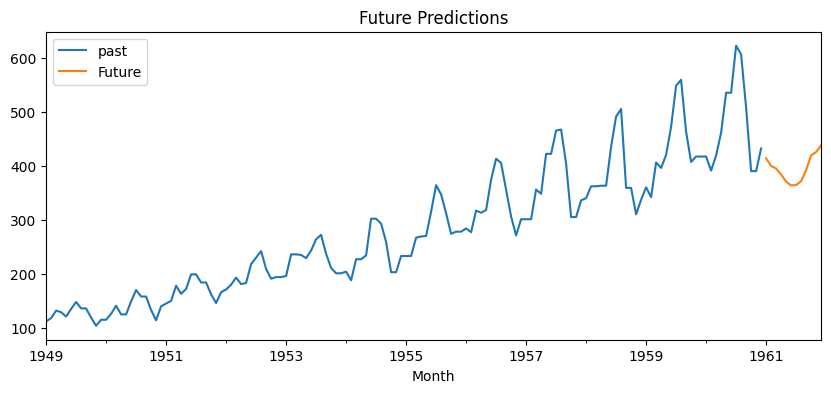

In [67]:
plt.figure(figsize=(10,4))
df['#Passengers'].ffill().plot(label='past')
forecast.plot(label='Future')

plt.legend()
plt.title('Future Predictions')
plt.show()

In [68]:
joblib.dump(final_model, r"models\sarimax.pkl")

['models\\sarimax.pkl']